In [29]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.impute import SimpleImputer

In [30]:
ko_data = pd.read_csv(r"C:\Users\marie\rep_codes\udder_project\udder_analysis\long_format_df\lactation_features.csv")
df = pd.read_csv(r"C:\Users\marie\rep_codes\udder_project\udder_processing\features_dict\gmfeature_table_cluster.csv")
print(df.shape)
df = df.dropna()
print(df.shape)
# mege data with kick off data 
df["min_teat"] = [np.nanmin(df.loc[i, ["rf_len", "rb_len", "lf_len", "lb_len"]]) for i in df.index]
df["max_teat"]= [np.nanmax(df.loc[i, ["rf_len", "rb_len", "lf_len", "lb_len"]]) for i in df.index]
df["mean_teat"]= [np.nanmean(df.loc[i, ["rf_len", "rb_len", "lf_len", "lb_len"]]) for i in df.index]
df["max_eu"] = [np.nanmean(df.loc[i, ["front_eu", "right_eu", "back_eu", "left_eu"]]) for i in df.index]
df["min_eu"] = [np.nanmean(df.loc[i, ["front_eu", "right_eu", "back_eu", "left_eu"]]) for i in df.index]
df["mean_eu"]= [np.nanmean(df.loc[i, ["front_eu", "right_eu", "back_eu", "left_eu"]]) for i in df.index]
df["max_gd"] = [np.nanmean(df.loc[i, ["front_gd", "right_gd", "back_gd", "left_gd"]]) for i in df.index]
df["min_gd"] = [np.nanmean(df.loc[i, ["front_gd", "right_gd", "back_gd", "left_gd"]]) for i in df.index]
df["mean_gd"] = [np.nanmean(df.loc[i, ["front_gd", "right_gd", "back_gd", "left_gd"]]) for i in df.index]
df2 = df[["cow", "udder_vol", "missing", "back_eu", "front_eu", "min_teat", "max_teat", "mean_teat", "max_eu", "min_eu", "mean_eu", "max_gd", "min_gd", "mean_gd"]].copy()
merged_df = ko_data.set_index("cow").join(df2.set_index("cow")).reset_index()
merged_df["parity"] = merged_df["lactation"]>1

(138, 44)
(129, 44)


In [36]:
X = merged_df[["udder_vol", "missing", "back_eu", "front_eu", "min_teat", "max_teat", "mean_teat", "max_eu", "min_eu", "mean_eu", "max_gd", "min_gd", "mean_gd", "parity"]]
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(X)
X = imp.transform(X)
scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)

C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

Distortion values:
1 : 131.6392680150209
2 : 88.33032762310921
3 : 72.91097872509881
4 : 65.77270745089038
5 : 58.501360535702844
6 : 53.65960579653188
7 : 47.85006596238149
8 : 43.14628713262427
9 : 39.26005751193787


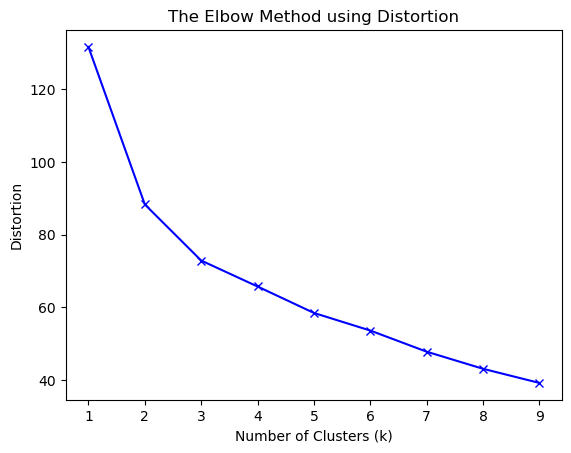

In [37]:
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X)
    
    distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])
    
    inertias.append(kmeanModel.inertia_)
    
    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

print("Distortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

In [44]:
kmeans = KMeans(n_clusters=4, random_state=5, n_init="auto").fit(X)
merged_df["cluster"] = kmeans.labels_

C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [48]:
# Train a classifier
# https://towardsdatascience.com/interpretable-k-means-clusters-feature-importances-7e516eeb8d3c/

clf = RandomForestClassifier(random_state=1)
clf.fit(X, merged_df["cluster"].values)

# Index sort the most important features
sorted_feature_weight_idxes = np.argsort(clf.feature_importances_)[::-1] # Reverse sort

# Get the most important features names and weights
most_important_features = np.take_along_axis(
    np.array(["udder_vol", "missing", "back_eu", "front_eu", "min_teat", "max_teat", "mean_teat", "max_eu", "min_eu", "mean_eu", "max_gd", "min_gd", "mean_gd", "parity"]), 
    sorted_feature_weight_idxes, axis=0)
most_important_weights = np.take_along_axis(
    np.array(clf.feature_importances_), 
    sorted_feature_weight_idxes, axis=0)

# Show
list(zip(most_important_features, most_important_weights))

[('max_teat', 0.15670055851905793),
 ('mean_teat', 0.14798407345900097),
 ('min_teat', 0.1300821113784178),
 ('min_gd', 0.10949752442272534),
 ('max_gd', 0.10786558061305025),
 ('mean_gd', 0.10241273602921631),
 ('mean_eu', 0.05084642931679253),
 ('min_eu', 0.04297213075819923),
 ('udder_vol', 0.039689960403085915),
 ('front_eu', 0.03846652747743833),
 ('back_eu', 0.03840187428866929),
 ('max_eu', 0.029948160909541922),
 ('missing', 0.003031408427987814),
 ('parity', 0.00210092399681626)]

<Axes: xlabel='cluster', ylabel='mean_teat'>

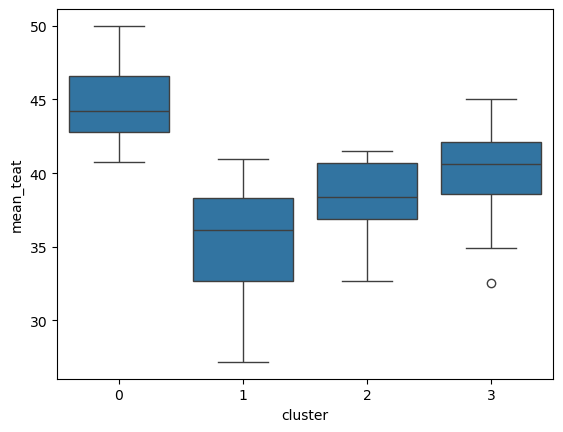

In [50]:
sns.boxplot(x = merged_df.cluster, y = merged_df.mean_teat)

<Axes: xlabel='cluster', ylabel='min_teat'>

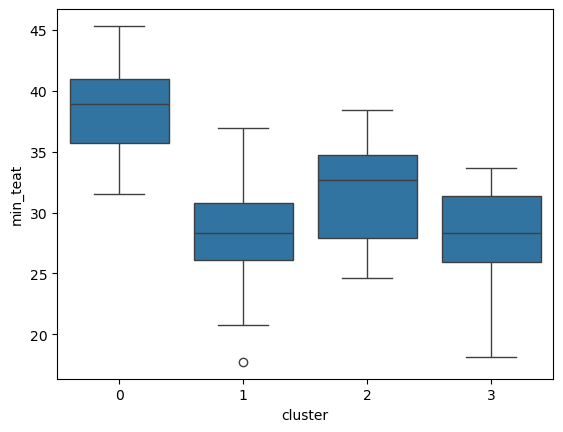

In [52]:
sns.boxplot(x = merged_df.cluster, y = merged_df.min_teat)

<Axes: xlabel='cluster', ylabel='max_teat'>

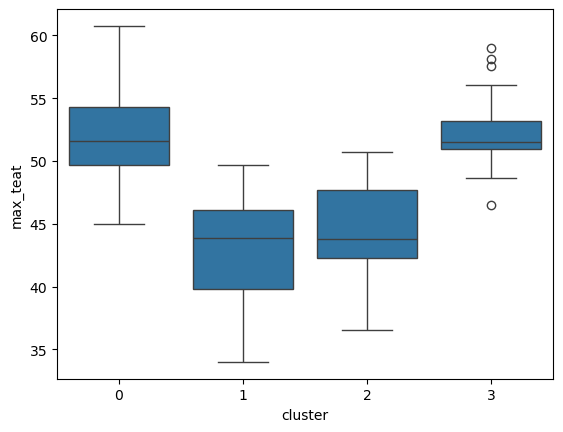

In [53]:
sns.boxplot(x = merged_df.cluster, y = merged_df.max_teat)

<Axes: xlabel='max_teat', ylabel='kickoff_any_sum'>

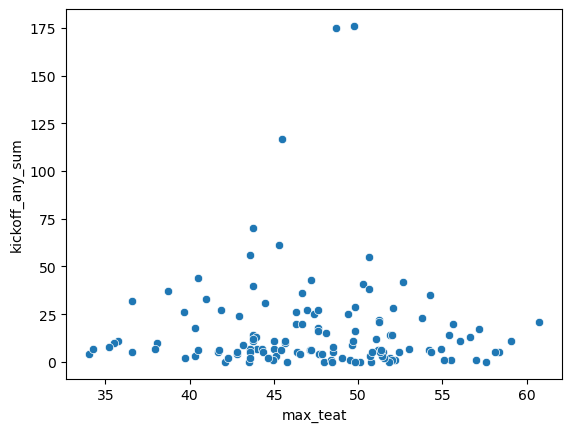

In [66]:
sns.scatterplot(x = merged_df.max_teat, y = merged_df.kickoff_any_sum)

<Axes: xlabel='min_eu', ylabel='min_teat'>

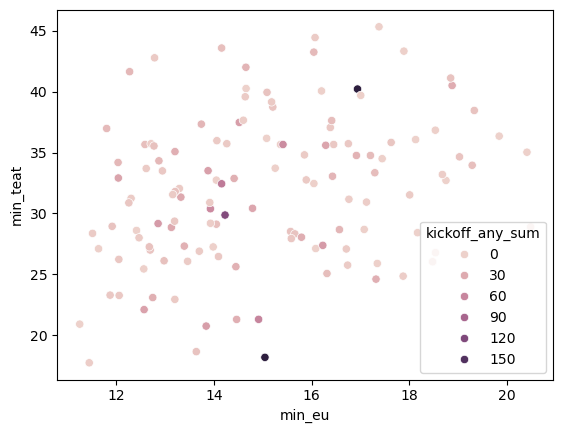

In [69]:
sns.scatterplot(x = merged_df.min_eu, y = merged_df.min_teat, hue = merged_df.kickoff_any_sum)

<Axes: xlabel='mean_teat', ylabel='max_teat'>

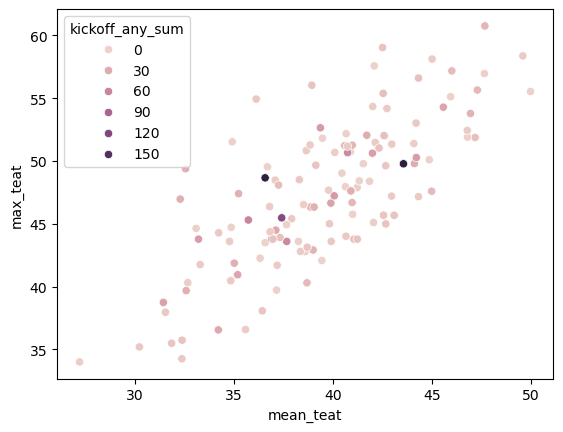

In [70]:
sns.scatterplot(x = merged_df.mean_teat, y = merged_df.max_teat, hue = merged_df.kickoff_any_sum)